# 전체 수강 기간 주차별 이탈 시점 EDA

## 분석 목적
- 전체 수강 기간에서 이탈이 집중되는 주차를 확인한다.
- 과목별 이탈률과 이탈 시점 차이를 비교한다.
- 이탈 예측 모델의 후보 주차를 선정한다.

## Target
- Withdrawn = 1
- Pass / Distinction / Fail = 0

In [29]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 프로젝트 루트 찾기
PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "interim"
    / "student_registration_merged_corrected.csv"
)

print("프로젝트 위치:", PROJECT_ROOT)
print("데이터 파일 존재:", DATA_PATH.exists())

# 데이터 불러오기
df = pd.read_csv(DATA_PATH, na_values=["?"])

print("데이터 크기:", df.shape)
display(df.head())

프로젝트 위치: /Users/kyungduck/Desktop/SKN_AI/SKAI 2차 프로젝트
데이터 파일 존재: True
데이터 크기: (32593, 23)


,code_module,code_presentation,id_student,gender,region,highest_education,highest_education_cd,imd_band,imd_band_cd,imd_band_missing,...,studied_credits,disability,final_result,target,date_registration,date_registration_missing,date_unregistration,unregister_yn,pre_course_unregister_yn,unregister_week
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,3,90-100%,9,0,...,240,N,Pass,0,-159.0,0,NaN,N,N,NaN
1,AAA,2013J,28400,F,Scotland,HE Qualification,3,20-30%,2,0,...,60,N,Pass,0,-53.0,0,NaN,N,N,NaN
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,2,30-40%,3,0,...,60,Y,Withdrawn,1,-92.0,0,12.0,Y,N,2.0
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,2,50-60%,5,0,...,60,N,Pass,0,-52.0,0,NaN,N,N,NaN
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,1,50-60%,5,0,...,60,N,Pass,0,-176.0,0,NaN,N,N,NaN


In [30]:
# 분석에 필요한 핵심 컬럼
key_cols = [
    "code_module",
    "code_presentation",
    "id_student"
]

# 날짜를 숫자형으로 통일
df["date_unregistration"] = pd.to_numeric(
    df["date_unregistration"],
    errors="coerce"
)

# Target 재검증
target_check = (df["final_result"] == "Withdrawn").astype(int)

print("===== 기본 데이터 점검 =====")
print("전체 수강 건수:", len(df))
print("학생-강좌 키 중복:", df.duplicated(key_cols).sum())
print("\nTarget 분포:")
print(df["target"].value_counts().sort_index())

print(
    "\nfinal_result와 target 불일치:",
    (df["target"] != target_check).sum()
)

# 이탈 시점 예외 확인
pre_course_withdrawn = (
    (df["target"] == 1)
    & (df["date_unregistration"] < 0)
).sum()

unknown_date_withdrawn = (
    (df["target"] == 1)
    & (df["date_unregistration"].isna())
).sum()

non_withdrawn_with_date = (
    (df["target"] == 0)
    & (df["date_unregistration"].notna())
).sum()

print("\n===== 이탈 날짜 예외 확인 =====")
print("개강 전 이탈:", pre_course_withdrawn)
print("이탈했지만 날짜 없음:", unknown_date_withdrawn)
print("비이탈인데 등록 취소 날짜 있음:", non_withdrawn_with_date)

===== 기본 데이터 점검 =====
전체 수강 건수: 32593
학생-강좌 키 중복: 0

Target 분포:
target
0    22437
1    10156
Name: count, dtype: int64

final_result와 target 불일치: 0

===== 이탈 날짜 예외 확인 =====
개강 전 이탈: 2676
이탈했지만 날짜 없음: 93
비이탈인데 등록 취소 날짜 있음: 9


In [31]:
# 개강 후 이탈했고 이탈 날짜가 확인되는 수강 건만 선택
timing_df = df.loc[
    (df["target"] == 1)
    & (df["date_unregistration"].notna())
    & (df["date_unregistration"] >= 0)
].copy()

# VLE와 동일한 주차 계산 기준
# 0~6일 = 1주차, 7~13일 = 2주차
timing_df["withdraw_week"] = (
    timing_df["date_unregistration"] // 7 + 1
).astype(int)

print("분석 대상 이탈 건수:", len(timing_df))
print(
    "이탈 주차 범위:",
    timing_df["withdraw_week"].min(),
    "~",
    timing_df["withdraw_week"].max()
)

print("\n이탈 건수가 많은 주차:")
display(
    timing_df["withdraw_week"]
    .value_counts()
    .sort_values(ascending=False)
    .head(10)
    .rename_axis("withdraw_week")
    .reset_index(name="dropout_count")
)

분석 대상 이탈 건수: 7387
이탈 주차 범위: 1 ~ 64

이탈 건수가 많은 주차:


,withdraw_week,dropout_count
0,2,1068
1,1,713
2,4,360
3,5,303
4,8,256
5,7,246
6,9,230
7,10,220
8,15,218
9,6,216


,withdraw_week,dropout_count
0,1,713
1,2,1068
2,3,215
3,4,360
4,5,303
5,6,216
6,7,246
7,8,256
8,9,230
9,10,220


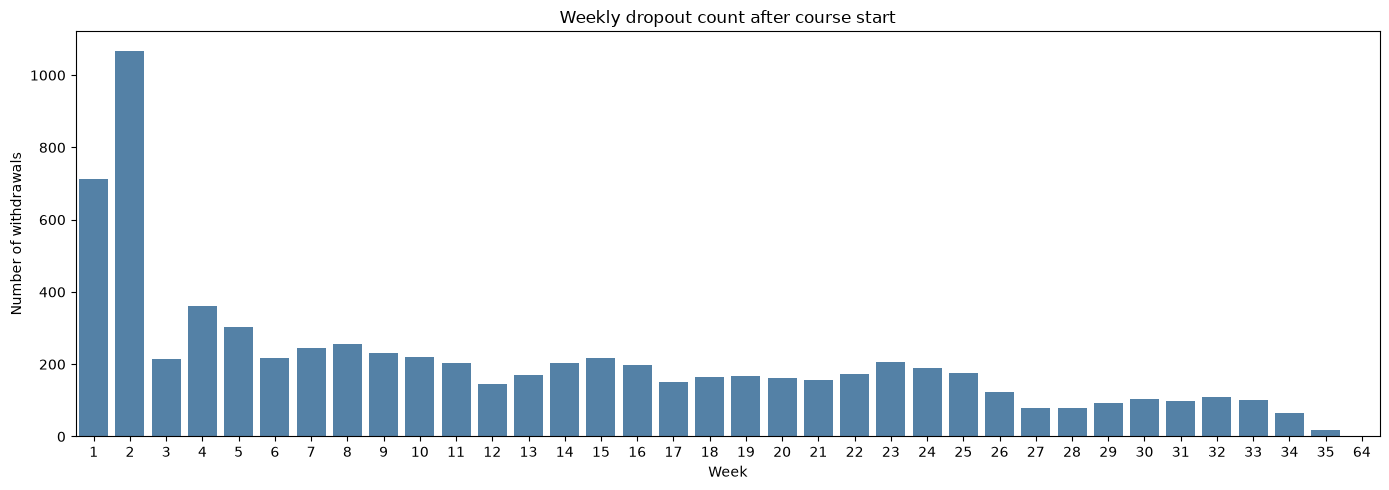

In [32]:
weekly_dropout = (
    timing_df.groupby("withdraw_week")
    .size()
    .rename("dropout_count")
    .reset_index()
    .sort_values("withdraw_week")
)

display(weekly_dropout.head(15))

plt.figure(figsize=(14, 5))

sns.barplot(
    data=weekly_dropout,
    x="withdraw_week",
    y="dropout_count",
    color="steelblue"
)

plt.title("Weekly dropout count after course start")
plt.xlabel("Week")
plt.ylabel("Number of withdrawals")
plt.tight_layout()
plt.show()

In [33]:
# 일반적인 수강 기간을 벗어난 이탈 기록 확인
outlier_withdrawals = timing_df.loc[
    timing_df["withdraw_week"] > 39,
    [
        "code_module",
        "code_presentation",
        "id_student",
        "final_result",
        "date_unregistration",
        "withdraw_week"
    ]
]

print("39주 초과 이탈 기록:", len(outlier_withdrawals))
display(outlier_withdrawals)

timing_valid = timing_df.loc[
    timing_df["withdraw_week"].between(1, 39)
].copy()

print("정상 범위 이탈 건수:", len(timing_valid))
print("분석 제외 건수:", len(timing_df) - len(timing_valid))

39주 초과 이탈 기록: 1


,code_module,code_presentation,id_student,final_result,date_unregistration,withdraw_week
25249,FFF,2013J,586851,Withdrawn,444.0,64


정상 범위 이탈 건수: 7386
분석 제외 건수: 1


In [34]:
COURSES_PATH = PROJECT_ROOT / "data" / "raw" / "courses.csv"

print("courses.csv 위치:", COURSES_PATH)
print("courses.csv 존재:", COURSES_PATH.exists())

courses.csv 위치: /Users/kyungduck/Desktop/SKN_AI/SKAI 2차 프로젝트/data/raw/courses.csv
courses.csv 존재: True


In [35]:
COURSES_PATH = PROJECT_ROOT / "data" / "raw" / "courses.csv"

print("courses.csv 존재:", COURSES_PATH.exists())

courses = pd.read_csv(COURSES_PATH)

print("courses 데이터 크기:", courses.shape)
display(courses.head())

print(
    "강좌 기간 범위:",
    courses["module_presentation_length"].min(),
    "~",
    courses["module_presentation_length"].max(),
    "일"
)

courses.csv 존재: True
courses 데이터 크기: (22, 3)


,code_module,code_presentation,module_presentation_length
0,AAA,2013J,268
1,AAA,2014J,269
2,BBB,2013J,268
3,BBB,2014J,262
4,BBB,2013B,240


강좌 기간 범위: 234 ~ 269 일


In [36]:
course_keys = ["code_module", "code_presentation"]

course_info = courses[
    course_keys + ["module_presentation_length"]
].drop_duplicates()

# 학생-강좌 데이터에 강좌 운영 기간 연결
analysis_df = df.merge(
    course_info,
    on=course_keys,
    how="left",
    validate="many_to_one"
)

print("강좌 정보 행 수:", len(course_info))
print("강좌 키 중복:", course_info.duplicated(course_keys).sum())
print(
    "강좌 기간 연결 실패:",
    analysis_df["module_presentation_length"].isna().sum()
)

print(
    "강좌 운영 기간:",
    analysis_df["module_presentation_length"].min(),
    "~",
    analysis_df["module_presentation_length"].max(),
    "일"
)

valid_withdraw_mask = (
    (analysis_df["target"] == 1)
    & (analysis_df["date_unregistration"].notna())
    & (analysis_df["date_unregistration"] >= 0)
    & (
        analysis_df["date_unregistration"]
        < analysis_df["module_presentation_length"]
    )
)

analysis_df["withdraw_week_valid"] = (
    analysis_df["date_unregistration"] // 7 + 1
).where(valid_withdraw_mask).astype("Int64")

print("강좌 기간 내 이탈 건수:", valid_withdraw_mask.sum())

print(
    "강좌 종료 후 이탈 기록:",
    (
        (analysis_df["target"] == 1)
        & (
            analysis_df["date_unregistration"]
            >= analysis_df["module_presentation_length"]
        )
    ).sum()
)

강좌 정보 행 수: 22
강좌 키 중복: 0
강좌 기간 연결 실패: 0
강좌 운영 기간: 234 ~ 269 일
강좌 기간 내 이탈 건수: 7386
강좌 종료 후 이탈 기록: 1


In [37]:
# 날짜 자료형 정리
analysis_df["date_registration"] = pd.to_numeric(
    analysis_df["date_registration"],
    errors="coerce"
)

# 등록일이 없는 45건은 강좌 시작일에 등록된 것으로 가정
analysis_df["registration_day_for_rate"] = (
    analysis_df["date_registration"].fillna(0)
)

# 이탈 시점 분석 대상
# 비이탈자 + 강좌 운영 기간 내 이탈자
rate_base = analysis_df.loc[
    (analysis_df["target"] == 0)
    | valid_withdraw_mask
].copy()

print("이탈률 분석 대상:", len(rate_base))

course_week_rows = []

for course in course_info.itertuples(index=False):
    module = course.code_module
    presentation = course.code_presentation
    course_length = int(course.module_presentation_length)

    course_students = rate_base.loc[
        (rate_base["code_module"] == module)
        & (rate_base["code_presentation"] == presentation)
    ]

    last_week = int(np.ceil(course_length / 7))

    for week in range(1, last_week + 1):
        week_start = (week - 1) * 7
        week_end = min(week * 7 - 1, course_length - 1)

        # 주차 시작 시점에 등록되어 있고 아직 이탈하지 않은 학생
        at_risk_mask = (
            course_students["registration_day_for_rate"].le(week_start)
            & (
                course_students["target"].eq(0)
                | course_students["date_unregistration"].ge(week_start)
            )
        )

        # 해당 주차에 이탈한 학생
        dropout_mask = (
            at_risk_mask
            & course_students["target"].eq(1)
            & course_students["date_unregistration"].between(
                week_start,
                week_end
            )
        )

        course_week_rows.append({
            "code_module": module,
            "code_presentation": presentation,
            "week_index": week,
            "at_risk_count": int(at_risk_mask.sum()),
            "dropout_count": int(dropout_mask.sum())
        })

course_week_rate = pd.DataFrame(course_week_rows)

weekly_dropout_rate = (
    course_week_rate
    .groupby("week_index", as_index=False)[
        ["at_risk_count", "dropout_count"]
    ]
    .sum()
)

weekly_dropout_rate["dropout_rate"] = (
    weekly_dropout_rate["dropout_count"]
    / weekly_dropout_rate["at_risk_count"]
)

weekly_dropout_rate["dropout_rate_pct"] = (
    weekly_dropout_rate["dropout_rate"] * 100
)

display(weekly_dropout_rate.head(15))

print(
    "주차 시작 기준 이탈 건수 합계:",
    weekly_dropout_rate["dropout_count"].sum()
)

이탈률 분석 대상: 29823


,week_index,at_risk_count,dropout_count,dropout_rate,dropout_rate_pct
0,1,29591,713,0.024095,2.409516
1,2,29018,1068,0.036805,3.680474
2,3,27985,214,0.007647,0.764695
3,4,27802,360,0.012949,1.294871
4,5,27451,303,0.011038,1.103785
5,6,27149,216,0.007956,0.795609
6,7,26936,246,0.009133,0.913276
7,8,26693,256,0.009591,0.959053
8,9,26437,230,0.008700,0.869993
9,10,26208,220,0.008394,0.839438


주차 시작 기준 이탈 건수 합계: 7385


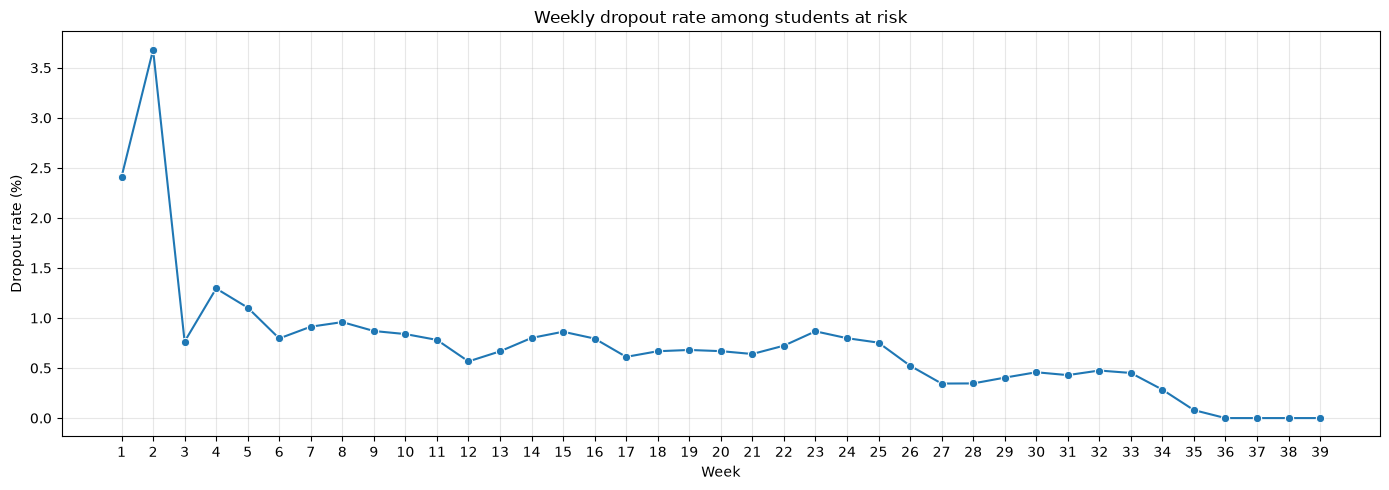

In [38]:
plt.figure(figsize=(14, 5))

sns.lineplot(
    data=weekly_dropout_rate,
    x="week_index",
    y="dropout_rate_pct",
    marker="o"
)

plt.title("Weekly dropout rate among students at risk")
plt.xlabel("Week")
plt.ylabel("Dropout rate (%)")
plt.xticks(weekly_dropout_rate["week_index"])
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [39]:
weekly_dropout_rate = weekly_dropout_rate.sort_values(
    "week_index"
).reset_index(drop=True)

total_timed_dropouts = weekly_dropout_rate["dropout_count"].sum()

weekly_dropout_rate["cumulative_dropouts"] = (
    weekly_dropout_rate["dropout_count"].cumsum()
)

weekly_dropout_rate["cumulative_dropout_pct"] = (
    weekly_dropout_rate["cumulative_dropouts"]
    / total_timed_dropouts
    * 100
)

# 이탈률이 높은 주차
top_dropout_weeks = (
    weekly_dropout_rate[
        [
            "week_index",
            "at_risk_count",
            "dropout_count",
            "dropout_rate_pct"
        ]
    ]
    .sort_values("dropout_rate_pct", ascending=False)
    .head(10)
)

print("===== 이탈률이 높은 주차 =====")
display(top_dropout_weeks.round(2))

# 주요 주차까지 누적된 이탈 비율
summary_weeks = [1, 2, 3, 4, 5, 8, 10, 15, 20]

cumulative_summary = weekly_dropout_rate.loc[
    weekly_dropout_rate["week_index"].isin(summary_weeks),
    [
        "week_index",
        "dropout_count",
        "dropout_rate_pct",
        "cumulative_dropouts",
        "cumulative_dropout_pct"
    ]
]

print("===== 주요 주차별 누적 이탈 =====")
display(cumulative_summary.round(2))

===== 이탈률이 높은 주차 =====


,week_index,at_risk_count,dropout_count,dropout_rate_pct
1,2,29018,1068,3.68
0,1,29591,713,2.41
3,4,27802,360,1.29
4,5,27451,303,1.10
7,8,26693,256,0.96
6,7,26936,246,0.91
8,9,26437,230,0.87
22,23,23878,207,0.87
14,15,25268,218,0.86
9,10,26208,220,0.84


===== 주요 주차별 누적 이탈 =====


,week_index,dropout_count,dropout_rate_pct,cumulative_dropouts,cumulative_dropout_pct
0,1,713,2.41,713,9.65
1,2,1068,3.68,1781,24.12
2,3,214,0.76,1995,27.01
3,4,360,1.29,2355,31.89
4,5,303,1.10,2658,35.99
7,8,256,0.96,3376,45.71
9,10,220,0.84,3826,51.81
14,15,218,0.86,4768,64.56
19,20,163,0.67,5614,76.02


In [40]:
weekly_dropout_rate = weekly_dropout_rate.sort_values(
    "week_index"
).reset_index(drop=True)

total_timed_dropouts = weekly_dropout_rate["dropout_count"].sum()

weekly_dropout_rate["cumulative_dropouts"] = (
    weekly_dropout_rate["dropout_count"].cumsum()
)

weekly_dropout_rate["cumulative_dropout_pct"] = (
    weekly_dropout_rate["cumulative_dropouts"]
    / total_timed_dropouts
    * 100
)

# 이탈률이 높은 주차
top_dropout_weeks = (
    weekly_dropout_rate[
        [
            "week_index",
            "at_risk_count",
            "dropout_count",
            "dropout_rate_pct"
        ]
    ]
    .sort_values("dropout_rate_pct", ascending=False)
    .head(10)
)

print("===== 이탈률이 높은 주차 =====")
display(top_dropout_weeks.round(2))

# 주요 시점까지 누적 이탈 비율
summary_weeks = [1, 2, 3, 4, 5, 8, 10, 15, 20]

cumulative_summary = weekly_dropout_rate.loc[
    weekly_dropout_rate["week_index"].isin(summary_weeks),
    [
        "week_index",
        "dropout_count",
        "dropout_rate_pct",
        "cumulative_dropouts",
        "cumulative_dropout_pct"
    ]
]

print("===== 주요 주차별 누적 이탈 =====")
display(cumulative_summary.round(2))


===== 이탈률이 높은 주차 =====


,week_index,at_risk_count,dropout_count,dropout_rate_pct
1,2,29018,1068,3.68
0,1,29591,713,2.41
3,4,27802,360,1.29
4,5,27451,303,1.10
7,8,26693,256,0.96
6,7,26936,246,0.91
8,9,26437,230,0.87
22,23,23878,207,0.87
14,15,25268,218,0.86
9,10,26208,220,0.84


===== 주요 주차별 누적 이탈 =====


,week_index,dropout_count,dropout_rate_pct,cumulative_dropouts,cumulative_dropout_pct
0,1,713,2.41,713,9.65
1,2,1068,3.68,1781,24.12
2,3,214,0.76,1995,27.01
3,4,360,1.29,2355,31.89
4,5,303,1.10,2658,35.99
7,8,256,0.96,3376,45.71
9,10,220,0.84,3826,51.81
14,15,218,0.86,4768,64.56
19,20,163,0.67,5614,76.02


In [41]:
# 과목별 전체 이탈률
module_overall = (
    analysis_df
    .groupby("code_module", as_index=False)
    .agg(
        enrollment_count=("id_student", "size"),
        dropout_count=("target", "sum")
    )
)

module_overall["dropout_rate_pct"] = (
    module_overall["dropout_count"]
    / module_overall["enrollment_count"]
    * 100
)

# 강좌 운영 기간 내 이탈자만 이용한 이탈 시점 통계
module_timing = (
    analysis_df.loc[valid_withdraw_mask]
    .groupby("code_module", as_index=False)
    .agg(
        timed_dropout_count=("id_student", "size"),
        median_withdraw_week=("withdraw_week_valid", "median")
    )
)

# 과목별 이탈 주차 최빈값과 해당 건수
module_mode = (
    analysis_df.loc[valid_withdraw_mask]
    .groupby(
        ["code_module", "withdraw_week_valid"],
        as_index=False
    )
    .size()
    .rename(columns={"size": "mode_count"})
    .sort_values(
        ["code_module", "mode_count", "withdraw_week_valid"],
        ascending=[True, False, True]
    )
    .drop_duplicates("code_module")
    .rename(
        columns={
            "withdraw_week_valid": "mode_withdraw_week"
        }
    )
)

# 최종 과목별 요약
module_summary = (
    module_overall
    .merge(module_timing, on="code_module", how="left")
    .merge(module_mode, on="code_module", how="left")
    .sort_values("dropout_rate_pct", ascending=False)
)

display(module_summary.round(2))

,code_module,enrollment_count,dropout_count,dropout_rate_pct,timed_dropout_count,median_withdraw_week,mode_withdraw_week,mode_count
2,CCC,4434,1975,44.54,1484,9.0,2,219
3,DDD,6272,2250,35.87,1717,12.0,2,182
5,FFF,7762,2403,30.96,1803,10.0,2,297
1,BBB,7909,2388,30.19,1517,8.0,2,248
4,EEE,2934,722,24.61,535,9.0,2,106
0,AAA,748,126,16.84,106,20.0,25,7
6,GGG,2534,292,11.52,224,15.0,19,12


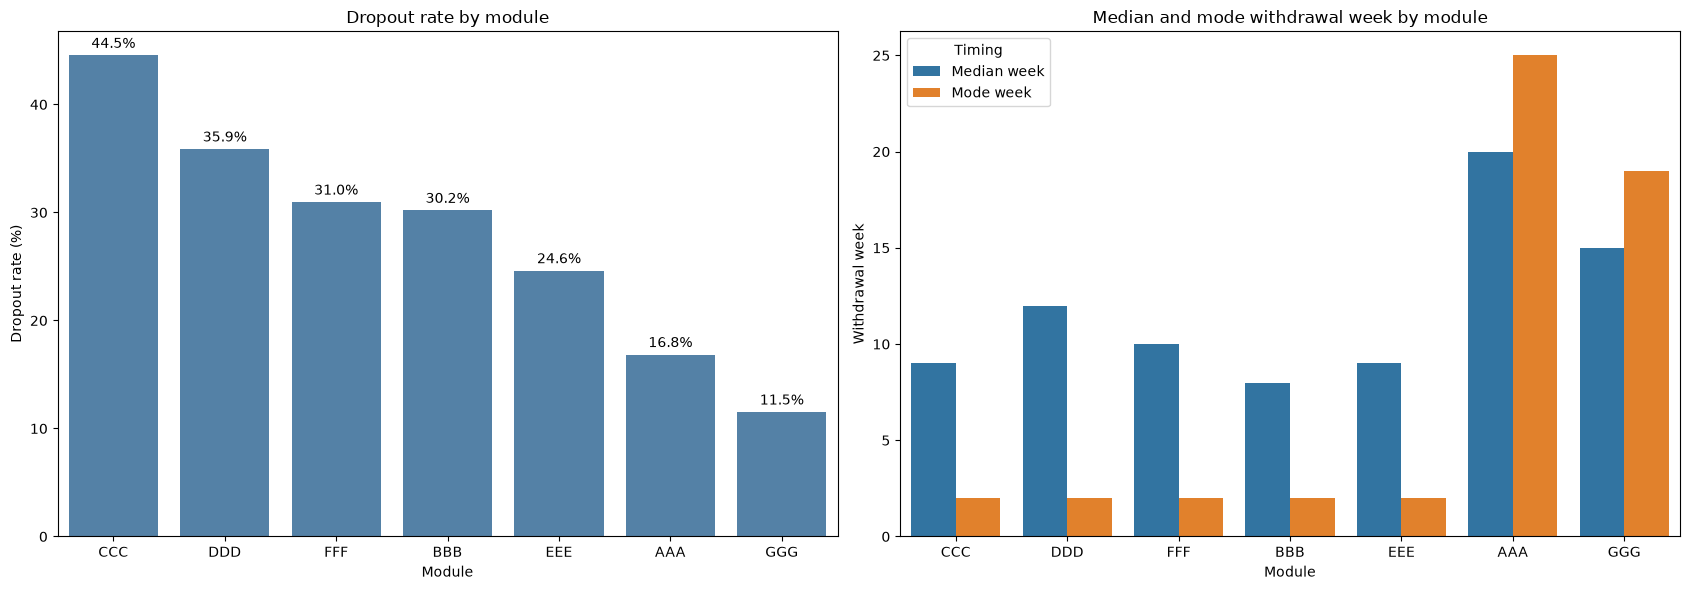

In [42]:
# 이탈률이 높은 과목 순서
module_order = (
    module_summary
    .sort_values("dropout_rate_pct", ascending=False)
    ["code_module"]
    .tolist()
)

# 중앙값과 최빈값을 그래프용 긴 형태로 변환
timing_plot = module_summary.melt(
    id_vars="code_module",
    value_vars=[
        "median_withdraw_week",
        "mode_withdraw_week"
    ],
    var_name="timing_type",
    value_name="week"
)

timing_plot["week"] = pd.to_numeric(
    timing_plot["week"],
    errors="coerce"
)

timing_plot["timing_type"] = timing_plot["timing_type"].replace({
    "median_withdraw_week": "Median week",
    "mode_withdraw_week": "Mode week"
})

fig, axes = plt.subplots(1, 2, figsize=(17, 6))

# 과목별 전체 이탈률
sns.barplot(
    data=module_summary,
    x="code_module",
    y="dropout_rate_pct",
    order=module_order,
    color="steelblue",
    ax=axes[0]
)

axes[0].set_title("Dropout rate by module")
axes[0].set_xlabel("Module")
axes[0].set_ylabel("Dropout rate (%)")

for container in axes[0].containers:
    axes[0].bar_label(
        container,
        fmt="%.1f%%",
        padding=3
    )

# 과목별 이탈 주차 중앙값과 최빈값
sns.barplot(
    data=timing_plot,
    x="code_module",
    y="week",
    hue="timing_type",
    order=module_order,
    ax=axes[1]
)

axes[1].set_title("Median and mode withdrawal week by module")
axes[1].set_xlabel("Module")
axes[1].set_ylabel("Withdrawal week")
axes[1].legend(title="Timing")

plt.tight_layout()
plt.show()



In [44]:
module_week_rate = (
    course_week_rate
    .groupby(
        ["code_module", "week_index"],
        as_index=False
    )
    .agg(
        at_risk_count=("at_risk_count", "sum"),
        dropout_count=("dropout_count", "sum")
    )
)

module_week_rate["dropout_rate_pct"] = (
    module_week_rate["dropout_count"]
    / module_week_rate["at_risk_count"]
    * 100
)

stable_module_week = module_week_rate[
    module_week_rate["at_risk_count"] >= 100
].copy()

module_peak_week = (
    stable_module_week
    .sort_values(
        ["code_module", "dropout_rate_pct"],
        ascending=[True, False]
    )
    .drop_duplicates("code_module")
    [
        [
            "code_module",
            "week_index",
            "at_risk_count",
            "dropout_count",
            "dropout_rate_pct"
        ]
    ]
    .sort_values("code_module")
)

print("과목별 최고 이탈률 주차 — 수강 중 인원 100명 이상")
display(module_peak_week.round(2))

과목별 최고 이탈률 주차 — 수강 중 인원 100명 이상


,code_module,week_index,at_risk_count,dropout_count,dropout_rate_pct
24,AAA,25,661,7,1.06
40,BBB,2,6755,248,3.67
79,CCC,2,3860,219,5.67
118,DDD,2,5565,182,3.27
156,EEE,2,2675,106,3.96
195,FFF,2,6983,297,4.25
251,GGG,19,2333,12,0.51


## 이탈 시점 EDA 결론

### 1. 전체 주차 분석

- 전체 이탈률은 2주차에 3.68%로 가장 높았다.
- 1주차 이탈률은 2.41%로 두 번째로 높았다.
- 전체 시점 확인 가능 이탈 중 약 24.1%가 2주차까지 발생했다.
- 5주차까지 약 36.0%, 10주차까지 약 51.8%가 누적되었다.
- 따라서 공통 초기 개입은 2주차 이탈이 발생하기 전인 개강 전 또는 1주차에 이루어져야 한다.

### 2. 과목별 분석

- CCC는 전체 이탈률이 44.5%로 가장 높았다.
- DDD, FFF, BBB도 약 30% 이상의 높은 이탈률을 보였다.
- BBB, CCC, DDD, EEE, FFF는 모두 2주차에 가장 높은 이탈률을 기록했다.
- AAA는 25주차, GGG는 19주차에 과목 내 최고 이탈률을 기록했다.
- 과목별로 이탈률과 위험 시점이 다르므로 공통 개입과 과목별 추가 개입이 함께 필요하다.

### 3. 다음 단계

- 1주차, 2주차, 4주차를 모델 후보 시점으로 비교한다.
- 각 후보 시점에 이미 이탈한 학생은 예측 대상에서 제외한다.
- Recall을 우선으로 비교하되, 성능이 안정적인 가장 빠른 주차를 골든타임으로 선정한다.
- VLE 클릭량, 활동일 수, 콘텐츠 다양성, 활동 유형별 클릭을 Target과 연결해 이탈·비이탈 행동 차이를 분석한다.